# **ІАД**

## **Лаб 1. Кацуба Тимофій КН-42**

In [ ]:
!pip install numpy pandas scikit-learn matplotlib plotly


Починаю завантаження MNIST (це може зайняти 1-2 хвилини, інтернет має бути увімкнений)...
Завантаження завершено!

Форма матриці X: (70000, 784)
Кількість унікальних міток у y: 10
Самі мітки класів: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']



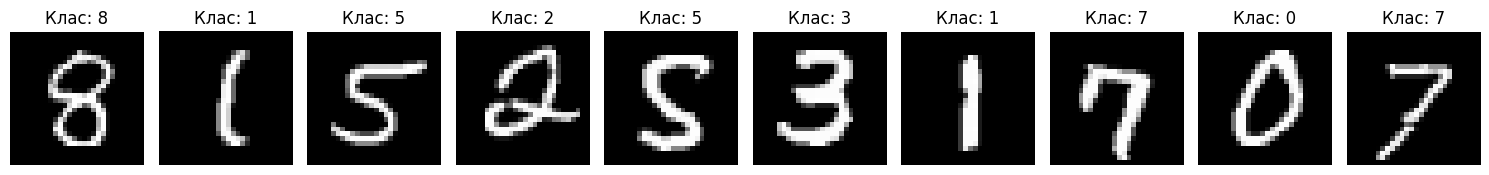

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print("Починаю завантаження MNIST ( 1-2 хвилини)...")
# Завантажуємо набір даних, як вимагається в умові
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
print("Завантаження завершено\n")

# Виводимо розмірності
print(f"Форма матриці X: {X.shape}")
print(f"Кількість унікальних міток у y: {len(np.unique(y))}")
print(f"Самі мітки класів: {np.unique(y)}\n")

# Вибираємо 10 випадкових картинок для огляду
random_indices = np.random.choise(X.shape[0], 10, replace=False)

# Малюємо ці 10 картинок
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i, ax in enumerate(axes):
    idx = random_indices[i]
    # Перетворюємо рядок із 784 чисел у двовимірну картинку 28x28
    image = X[idx].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Клас: {y[idx]}")
    ax.axis('off')
    
plt.tight_layout()
plt.show()


In [3]:
from sklearn.decomposition import PCA

print("Починаю математичне стиснення даних (PCA)")
# Створюємо екземпляр алгоритму і залишаємо лише 3 головні осі
pca = PCA(n_components=3)

# fit_transform робить дві речі: 
# 1. Аналізує всі 70000 картинок, шукаючи найважливіші закономірності (fit)
# 2. Перераховує кожну картинку у нових 3 координатах (transform)
X_pca = pca.fit_transform(X)
print("Стиснення завершено\n")

# Перевіряємо, чи отримали ми матрицю потрібного розміру (має бути 70000 на 3)
print(f"Форма нової матриці X_pca: {X_pca.shape}\n")

# Дивимось, скільки оригінальної інформації (дисперсії) вдалося зберегти
variance = pca.explained_variance_ratio_
print("Відсоток поясненої дисперсії (збереженої інформації):")
print(f"1-ша компонента: {variance[0]*100:.2f}%")
print(f"2-га компонента: {variance[1]*100:.2f}%")
print(f"3-тя компонента: {variance[2]*100:.2f}%")
print("-" * 30)
print(f"Загалом ці 3 числа описують лише {sum(variance)*100:.2f}% оригінальної інформації.")

Починаю математичне стиснення даних (PCA)...
Стиснення завершено!

Форма нової матриці X_pca: (70000, 3)

Відсоток поясненої дисперсії (збереженої інформації):
1-ша компонента: 9.75%
2-га компонента: 7.16%
3-тя компонента: 6.15%
------------------------------
Загалом ці 3 числа описують лише 23.05% оригінальної інформації.


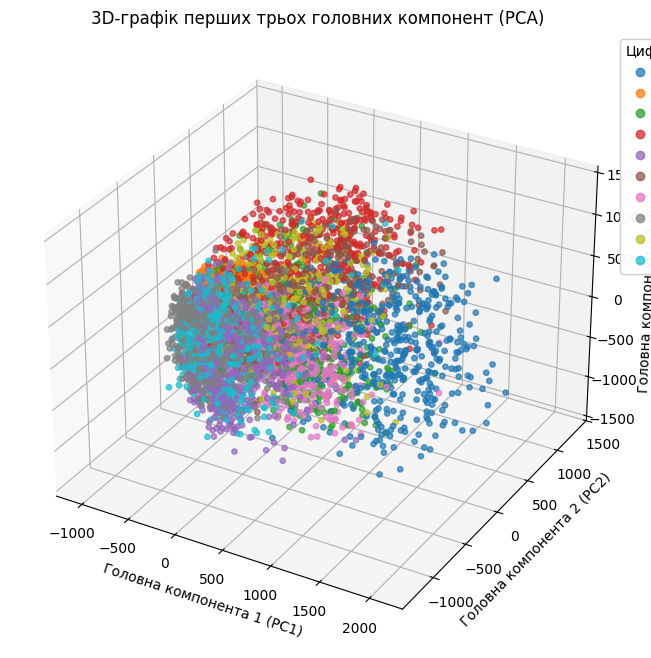

In [7]:
#3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Беремо лише перші 5000 точок для візуалізації
n_samples = 5000
x_pca_subset = X_pca[:n_samples]
y_subset = y[:n_samples].astype(int)  # Перетворюємо мітки з тексту в числа для кольорів

# Будуємо діаграму розсіювання (scatter plot)
# c=y_subset фарбує кожну точку у колір цифри від 0 до 9
scatter = ax.scatter(X_pca_subset[:, 0], X_pca_subset[:, 1], X_pca_subset[:, 2], 
                     c=y_subset, cmap='tab10', alpha=0.7, s=15)

# Додаємо легенду, щоб розуміти, який колір якій цифрі відповідає
legend = ax.legend(*scatter.legend_elements(), title="Цифри", bbox_to_anchor=(1.1, 1))
ax.add_artist(legend)

ax.set_title("3D-графік перших трьох головних компонент (PCA)")
ax.set_xlabel("Головна компонента 1 (PC1)")
ax.set_ylabel("Головна компонента 2 (PC2)")
ax.set_zlabel("Головна компонента 3 (PC3)")

fig.subplots_adjust(right=0.8)
plt.show()

Починаю реконструкцію зображень...
Реконструкція завершена!



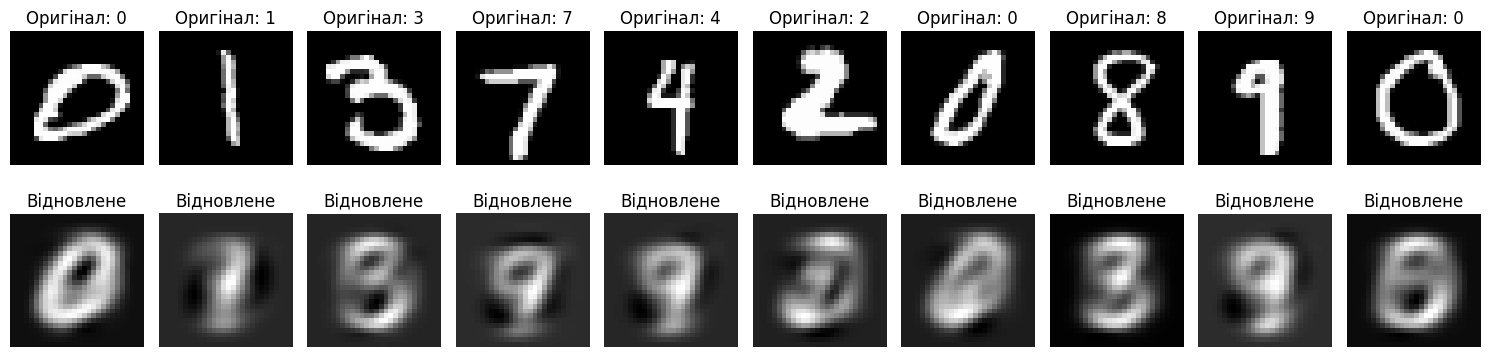

In [8]:
# Відновлюємо дані з 3 компонент назад у 784 виміри
print("Починаю реконструкцію зображень")
X_reconstructed = pca.inverse_transform(X_pca)
print("Реконструкція завершена\n")

# Вибираємо 10 випадкових картинок для порівняння
random_indices = np.random.choise(X.shape[0], 10, replace=False)

# Створюємо графік: 2 рядки і 10 колонок
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, idx in enumerate(random_indices):
     # Верхній рядок: Оригінальні зображення
     orig_image = X[idx].reshape(28, 28)
     axes[0, i].imshow(orig_image, cmap='gray')
     axes[0, i].set_title(f"Оригінал: {y[idx]}")
     axes[0, i].axis('off')
     
      # Нижній рядок: Реконструйовані зображення
      recon_image = X_reconstructed[idx].reshape(28, 28)
      axes[1, i].imshow(recon_image, cmap='gray')
      axes[1, i].set_title("Відновлене")
      axes[1, i].axis('off')
      
plt.tight_layout()
plt.show()

Починаємо розрахунки для різних значень k. Це займе близько 30-60 секунд...
Розрахунки завершено! Будуємо графіки...


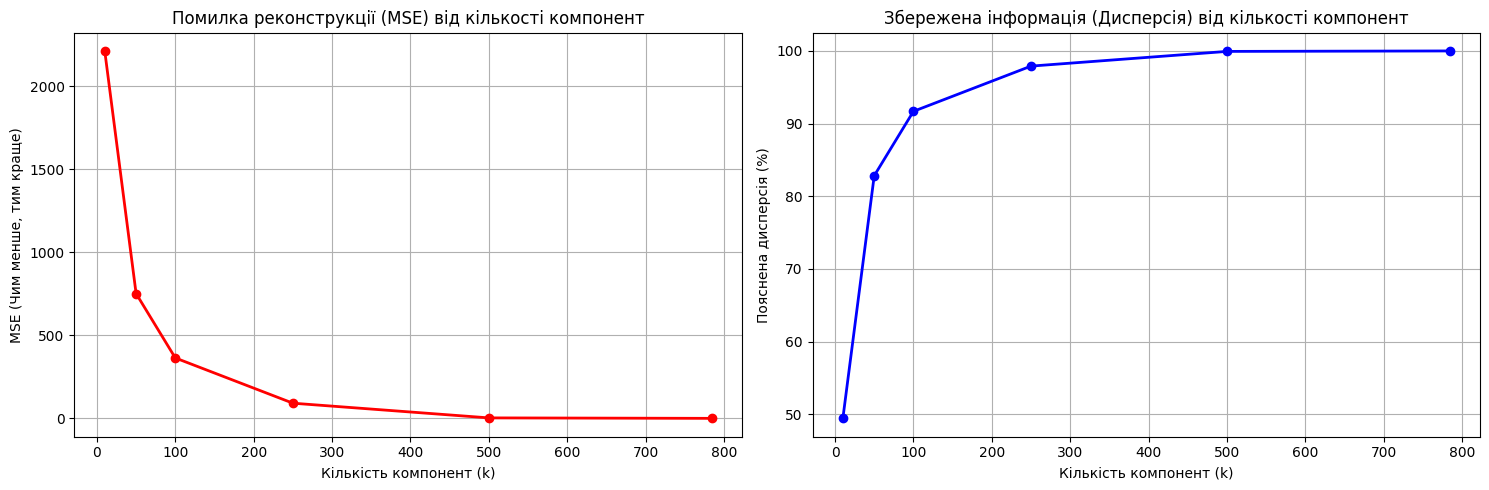

In [9]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Починаємо розрахунки для різних значень k. Це займе близько 30-60 секунд...")

# Беремо різні рівні стиснення: від екстремального (10) до повної відсутності стиснення (784)
k_values = [10, 50, 100, 250, 500, 784]

mse_scores = []
variance_scores = []

# Для швидкості розрахунків візьмемо не всі 70000 картинок, а перші 10000. 
# Цього більш ніж достатньо для точного графіка.
X_subset = X[:10000]

for k in k_values:
    # 1. Налаштовуємо PCA на поточну кількість компонент k
    pca_k = PCA(n_components=k)
    
    # 2. Стискаємо дані
    X_compressed = pca_k.fit_transform(X_subset)
    
    # 3. Відновлюємо дані назад у 784 пікселі
    X_restored = pca_k.inverse_transform(X_compressed)
    
    # 4. Рахуємо помилку MSE (різниця між оригіналом і відновленою версією в квадраті)
    mse = np.mean((X_subset - X_restored) ** 2)
    mse_scores.append(mse)
    
    # 5. Рахуємо сумарну збережену дисперсію
    var = sum(pca_k.explained_variance_ratio_) * 100
    variance_scores.append(var)

print("Розрахунки завершено! Будуємо графіки...")

# Будуємо два графіки поруч
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Графік 1: Помилка MSE
ax1.plot(k_values, mse_scores, marker='o', color='red', linewidth=2)
ax1.set_title("Помилка реконструкції (MSE) від кількості компонент")
ax1.set_xlabel("Кількість компонент (k)")
ax1.set_ylabel("MSE (Чим менше, тим краще)")
ax1.grid(True)

# Графік 2: Пояснена дисперсія
ax2.plot(k_values, variance_scores, marker='o', color='blue', linewidth=2)
ax2.set_title("Збережена інформація (Дисперсія) від кількості компонент")
ax2.set_xlabel("Кількість компонент (k)")
ax2.set_ylabel("Пояснена дисперсія (%)")
ax2.grid(True)

plt.tight_layout()
plt.show()